# Adversarial Transferability to HOG-Based Classifiers
## Publication-Quality Figures for Conference Paper

This notebook generates **8 targeted figures** that visually support the paper's key findings without duplicating tabular data.

### Key Findings to Visualize:
1. HOG provides no inherent robustness (all classifiers degrade)
2. FGSM transfers MORE effectively than PGD (surprising reversal)
3. Epsilon sensitivity is nonlinear (doubling ε → 20-30pp more drop)
4. Block size provides modest mitigation
5. Cross-paradigm comparison (HOG vs CNN transfer baseline)

### Note on Statistics:
- Each configuration was run **ONCE**, so we cannot show confidence intervals
- Variation shown is **ACROSS configurations**, not repeated trials
- Correlations measure **configuration sensitivity**, not measurement uncertainty

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from math import pi
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Publication Style Configuration

In [2]:
# Publication-quality settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': '0.8',
    'legend.fancybox': False,
})

# Colorblind-friendly palette
COLORS = {
    'KNN': '#0077BB',      # Blue
    'DT': '#EE7733',       # Orange  
    'LSVM': '#009988',     # Teal
    'KSVM': '#CC3311',     # Red
    'ANN': '#AA4499',      # Purple
    'VGG': '#332288',      # Dark purple
    'AlexNet': '#88CCEE',  # Light blue
}

MARKERS = {
    'KNN': 'o', 'DT': 's', 'LSVM': '^', 'KSVM': 'D', 
    'ANN': 'p', 'VGG': 'X', 'AlexNet': 'P'
}

print("Style configured!")

Style configured!


## Data Loading

**Update the paths below** to point to your local JSON files.

In [3]:
# ============================================================
# UPDATE THESE PATHS TO YOUR LOCAL FILE LOCATIONS
# ============================================================
RESULTS_PATH = '/home/achraf/Research/MLHACK_PAPER/JSONS/experiment_results.json'       # Classical ML results
ANN_RESULTS_PATH = '/home/achraf/Research/MLHACK_PAPER/JSONS/experiment_results_ANN.json'  # ANN results
CONFIGS_PATH = '/home/achraf/Research/MLHACK_PAPER/JSONS/configs.json'                  # HOG configurations

# Load data
with open(RESULTS_PATH, 'r') as f:
    results = json.load(f)
    
with open(ANN_RESULTS_PATH, 'r') as f:
    results_ann = json.load(f)
    
with open(CONFIGS_PATH, 'r') as f:
    configs = json.load(f)

print(f"Loaded {len(results)} experiments")
print(f"Loaded {len(configs)} HOG configurations")

Loaded 8 experiments
Loaded 8 HOG configurations


In [4]:
def prepare_dataframe():
    """Convert experiment results to structured DataFrame."""
    data = []
    classifiers = ['KNN', 'DT', 'LSVM', 'KSVM']
    
    for i, config in enumerate(configs):
        exp_key = f'EXPERIMENT{i}'
        
        for clf in classifiers:
            if exp_key in results and clf in results[exp_key]:
                data.append({
                    'experiment': i,
                    'classifier': clf,
                    'pipeline': 'HOG+Classical',
                    'cell_size': config['PXCELL'],
                    'orientations': config['ORIENTATIONS'],
                    'block_size': config['CELLBLOCK'],
                    'epsilon': config['EPS'],
                    'orig_acc': results[exp_key][clf]['orig_acc'],
                    'fsgm_acc': results[exp_key][clf]['fsgm_acc'],
                    'pgd_acc': results[exp_key][clf]['pgd_acc'],
                })
        
        # ANN results (skip failed C1 experiment)
        if exp_key in results_ann and 'ANN' in results_ann[exp_key]:
            ann_orig = results_ann[exp_key]['ANN']['orig_acc']
            if ann_orig > 0.15:  # Skip training failures
                data.append({
                    'experiment': i,
                    'classifier': 'ANN',
                    'pipeline': 'HOG+Neural',
                    'cell_size': config['PXCELL'],
                    'orientations': config['ORIENTATIONS'],
                    'block_size': config['CELLBLOCK'],
                    'epsilon': config['EPS'],
                    'orig_acc': ann_orig,
                    'fsgm_acc': results_ann[exp_key]['ANN']['fsgm_acc'],
                    'pgd_acc': results_ann[exp_key]['ANN']['pgd_acc'],
                })
    
    df = pd.DataFrame(data)
    
    # Compute derived metrics
    df['fsgm_drop'] = df['orig_acc'] - df['fsgm_acc']
    df['pgd_drop'] = df['orig_acc'] - df['pgd_acc']
    df['fsgm_rel_drop'] = (df['orig_acc'] - df['fsgm_acc']) / df['orig_acc'] * 100
    df['pgd_rel_drop'] = (df['orig_acc'] - df['pgd_acc']) / df['orig_acc'] * 100
    df['fsgm_retention'] = df['fsgm_acc'] / df['orig_acc'] * 100
    df['pgd_retention'] = df['pgd_acc'] / df['orig_acc'] * 100
    
    return df

# CNN Transfer Baseline (from paper Table 3)
cnn_data = pd.DataFrame([
    {'classifier': 'VGG', 'pipeline': 'End-to-End (Surrogate)', 
     'orig_acc': 0.98, 'fsgm_acc': 0.18, 'pgd_acc': 0.01},
    {'classifier': 'AlexNet', 'pipeline': 'End-to-End (Target)', 
     'orig_acc': 0.84, 'fsgm_acc': 0.71, 'pgd_acc': 0.77},
])
cnn_data['fsgm_rel_drop'] = (cnn_data['orig_acc'] - cnn_data['fsgm_acc']) / cnn_data['orig_acc'] * 100
cnn_data['pgd_rel_drop'] = (cnn_data['orig_acc'] - cnn_data['pgd_acc']) / cnn_data['orig_acc'] * 100

# Create DataFrame
df = prepare_dataframe()
print(f"Created DataFrame with {len(df)} rows")
df.head()

Created DataFrame with 39 rows


,experiment,classifier,pipeline,cell_size,orientations,block_size,epsilon,orig_acc,fsgm_acc,pgd_acc,fsgm_drop,pgd_drop,fsgm_rel_drop,pgd_rel_drop,fsgm_retention,pgd_retention
0,0,KNN,HOG+Classical,8,6,1,4,0.54322,0.30364,0.36986,0.23958,0.17336,44.103678,31.913405,55.896322,68.086595
1,0,DT,HOG+Classical,8,6,1,4,0.35226,0.20780,0.23380,0.14446,0.11846,41.009482,33.628570,58.990518,66.371430
2,0,LSVM,HOG+Classical,8,6,1,4,0.42032,0.27420,0.32458,0.14612,0.09574,34.763989,22.777884,65.236011,77.222116
3,0,KSVM,HOG+Classical,8,6,1,4,0.74328,0.30958,0.43240,0.43370,0.31088,58.349478,41.825422,41.650522,58.174578
4,1,KNN,HOG+Classical,6,6,1,4,0.52522,0.33638,0.38594,0.18884,0.13928,35.954457,26.518411,64.045543,73.481589


---
## Figure 1: Cross-Paradigm Comparison (CENTRAL RESULT)

**Purpose**: Visualize that HOG-based pipelines are vulnerable to CNN-crafted attacks, comparing against CNN transfer baseline.

**Paper Section**: Results - Cross-Paradigm Comparison

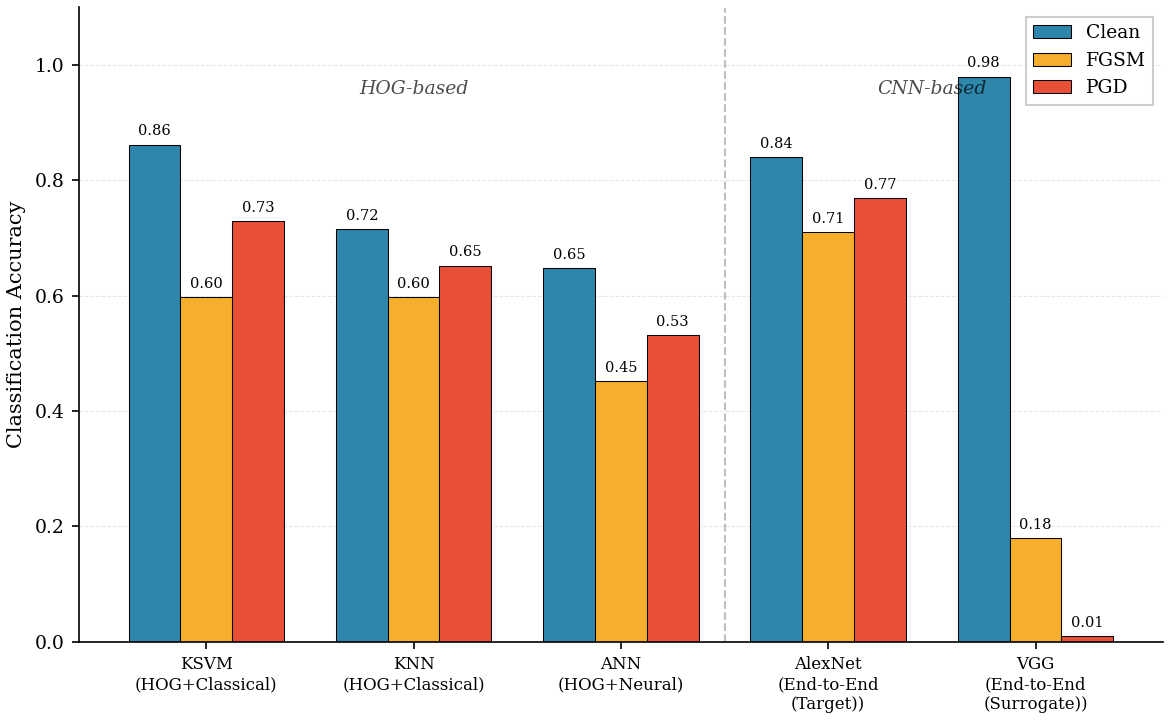

In [5]:
def figure1_cross_paradigm_comparison():
    """Cross-paradigm adversarial degradation comparison."""
    # Get C5 data (best config: block=3)
    c5 = df[df['experiment'] == 4].copy()
    
    models = ['KSVM', 'KNN', 'ANN', 'AlexNet', 'VGG']
    pipelines = ['HOG+Classical', 'HOG+Classical', 'HOG+Neural', 
                 'End-to-End\n(Target)', 'End-to-End\n(Surrogate)']
    
    orig_vals, fsgm_vals, pgd_vals = [], [], []
    
    for model in models:
        if model in ['VGG', 'AlexNet']:
            row = cnn_data[cnn_data['classifier'] == model].iloc[0]
        else:
            row = c5[c5['classifier'] == model].iloc[0]
        orig_vals.append(row['orig_acc'])
        fsgm_vals.append(row['fsgm_acc'])
        pgd_vals.append(row['pgd_acc'])
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(models))
    width = 0.25
    
    bars1 = ax.bar(x - width, orig_vals, width, label='Clean', 
                   color='#2E86AB', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, fsgm_vals, width, label='FGSM', 
                   color='#F6AE2D', edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, pgd_vals, width, label='PGD', 
                   color='#E94F37', edgecolor='black', linewidth=0.5)
    
    # Value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{m}\n({p})' for m, p in zip(models, pipelines)], fontsize=8)
    
    # Separator line
    ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(1, 0.95, 'HOG-based', ha='center', fontsize=9, style='italic', alpha=0.7)
    ax.text(3.5, 0.95, 'CNN-based', ha='center', fontsize=9, style='italic', alpha=0.7)
    
    ax.set_ylabel('Classification Accuracy')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

fig1 = figure1_cross_paradigm_comparison()
fig1.savefig('fig1_cross_paradigm_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 2: FGSM vs PGD Transfer (SURPRISING FINDING)

**Purpose**: Visualize that FGSM transfers MORE effectively than PGD to HOG features (opposite of typical DL hierarchy).

**Paper Section**: Discussion - FGSM vs PGD Transfer

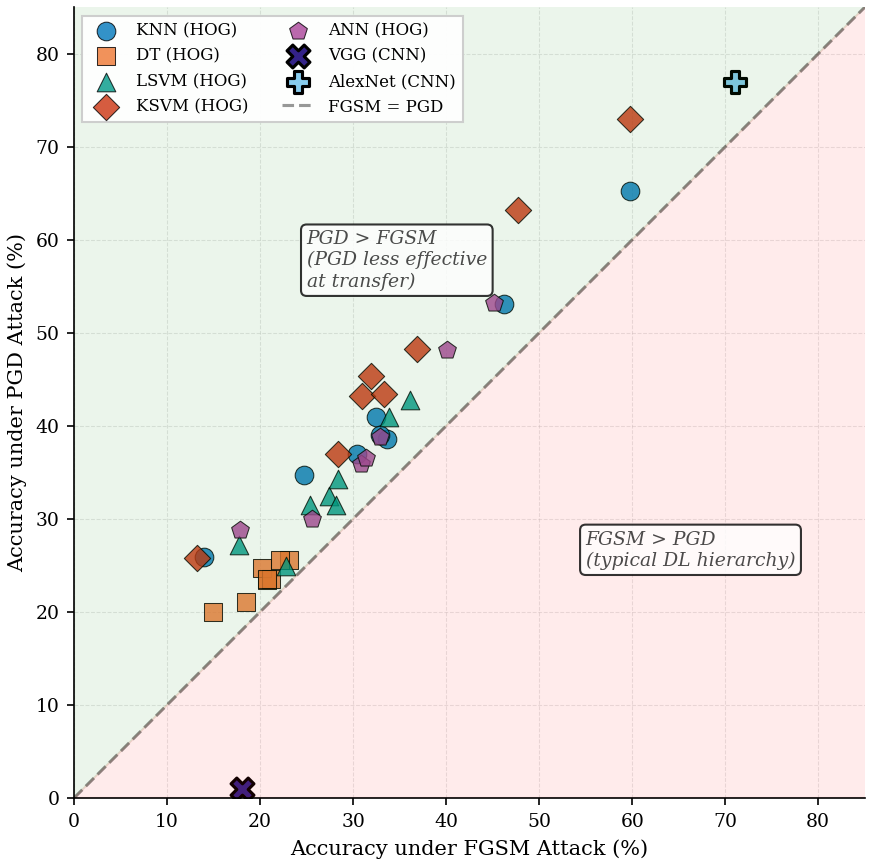

In [6]:
def figure2_fgsm_vs_pgd_scatter():
    """FGSM vs PGD accuracy scatter plot."""
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Plot HOG-based classifiers
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM', 'ANN']:
        clf_data = df[df['classifier'] == clf]
        if len(clf_data) == 0:
            continue
        ax.scatter(clf_data['fsgm_acc'] * 100, clf_data['pgd_acc'] * 100,
                  c=COLORS[clf], marker=MARKERS[clf], s=80, label=f'{clf} (HOG)',
                  edgecolors='black', linewidths=0.5, alpha=0.8)
    
    # Plot CNN baselines
    for _, row in cnn_data.iterrows():
        clf = row['classifier']
        ax.scatter(row['fsgm_acc'] * 100, row['pgd_acc'] * 100,
                  c=COLORS[clf], marker=MARKERS[clf], s=120, 
                  label=f'{clf} (CNN)', edgecolors='black', linewidths=1.5)
    
    # Diagonal reference
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.4, linewidth=1.5, label='FGSM = PGD')
    
    # Shade regions
    ax.fill_between([0, 100], [0, 100], [100, 100], alpha=0.08, color='green')
    ax.fill_between([0, 100], [0, 0], [0, 100], alpha=0.08, color='red')
    
    # Annotations
    ax.annotate('PGD > FGSM\n(PGD less effective\nat transfer)', 
               xy=(25, 55), fontsize=9, style='italic', alpha=0.7,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.annotate('FGSM > PGD\n(typical DL hierarchy)', 
               xy=(55, 25), fontsize=9, style='italic', alpha=0.7,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Accuracy under FGSM Attack (%)')
    ax.set_ylabel('Accuracy under PGD Attack (%)')
    ax.set_xlim(0, 85)
    ax.set_ylim(0, 85)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.set_aspect('equal')
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

fig2 = figure2_fgsm_vs_pgd_scatter()
fig2.savefig('fig2_fgsm_vs_pgd_transfer.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 3: Block Size Impact (MITIGATION ANALYSIS)

**Purpose**: Visualize that larger block sizes provide MODEST mitigation but cannot prevent transfer.

**Paper Section**: Discussion - HOG Parameter Impact

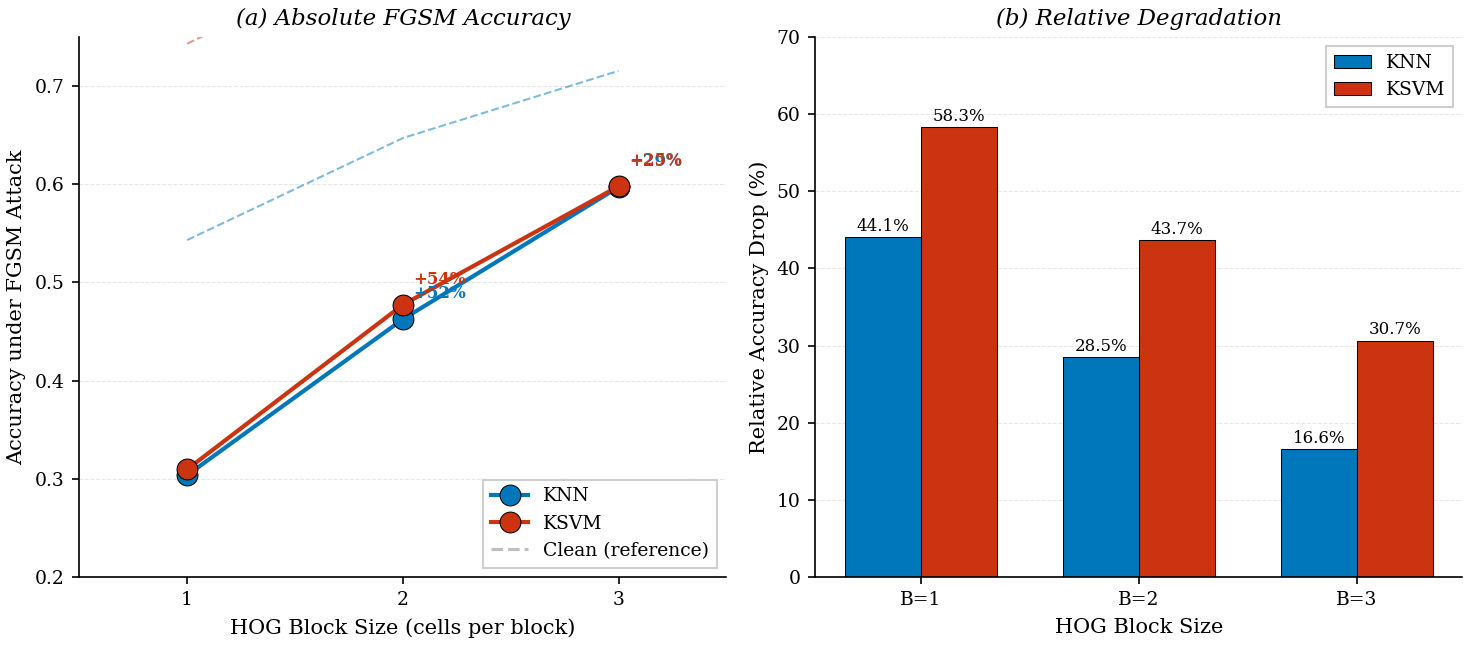

In [7]:
def figure3_block_size_impact():
    """Impact of HOG block size on adversarial robustness."""
    # Filter for block size experiments (C1=exp0, C4=exp3, C5=exp4)
    block_data = df[(df['experiment'].isin([0, 3, 4])) & 
                    (df['classifier'].isin(['KNN', 'KSVM']))].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # Left: Absolute accuracy under FGSM
    ax = axes[0]
    for clf in ['KNN', 'KSVM']:
        clf_data = block_data[block_data['classifier'] == clf].sort_values('block_size')
        
        # Clean accuracy (dashed reference)
        ax.plot(clf_data['block_size'], clf_data['orig_acc'], 
                '--', color=COLORS[clf], alpha=0.5, linewidth=1)
        
        # FGSM accuracy (solid)
        ax.plot(clf_data['block_size'], clf_data['fsgm_acc'], 
                'o-', color=COLORS[clf], label=f'{clf}',
                linewidth=2, markersize=10, markeredgecolor='black', markeredgewidth=0.5)
        
        # Improvement annotations
        fsgm_vals = clf_data['fsgm_acc'].values
        block_sizes = clf_data['block_size'].values
        for i in range(1, len(fsgm_vals)):
            improvement = (fsgm_vals[i] - fsgm_vals[i-1]) / fsgm_vals[i-1] * 100
            ax.annotate(f'+{improvement:.0f}%', 
                       xy=(block_sizes[i], fsgm_vals[i]),
                       xytext=(5, 10), textcoords='offset points',
                       fontsize=8, color=COLORS[clf], fontweight='bold')
    
    ax.set_xlabel('HOG Block Size (cells per block)')
    ax.set_ylabel('Accuracy under FGSM Attack')
    ax.set_xticks([1, 2, 3])
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(0.2, 0.75)
    ax.plot([], [], '--', color='gray', alpha=0.5, label='Clean (reference)')
    ax.legend(loc='lower right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title('(a) Absolute FGSM Accuracy', fontweight='normal', style='italic')
    
    # Right: Relative drop
    ax = axes[1]
    width = 0.35
    x = np.arange(3)
    
    for i, clf in enumerate(['KNN', 'KSVM']):
        clf_data = block_data[block_data['classifier'] == clf].sort_values('block_size')
        rel_drops = clf_data['fsgm_rel_drop'].values
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, rel_drops, width, label=clf,
                     color=COLORS[clf], edgecolor='black', linewidth=0.5)
        
        for bar, val in zip(bars, rel_drops):
            ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                       xytext=(0, 3), textcoords='offset points',
                       ha='center', fontsize=8)
    
    ax.set_xlabel('HOG Block Size')
    ax.set_ylabel('Relative Accuracy Drop (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(['B=1', 'B=2', 'B=3'])
    ax.set_ylim(0, 70)
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title('(b) Relative Degradation', fontweight='normal', style='italic')
    
    plt.tight_layout()
    return fig

fig3 = figure3_block_size_impact()
fig3.savefig('fig3_block_size_impact.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 4: Epsilon Sensitivity (NONLINEAR SCALING)

**Purpose**: Visualize that vulnerability scales NONLINEARLY with epsilon.

**Paper Section**: Discussion - Perturbation Budget Sensitivity

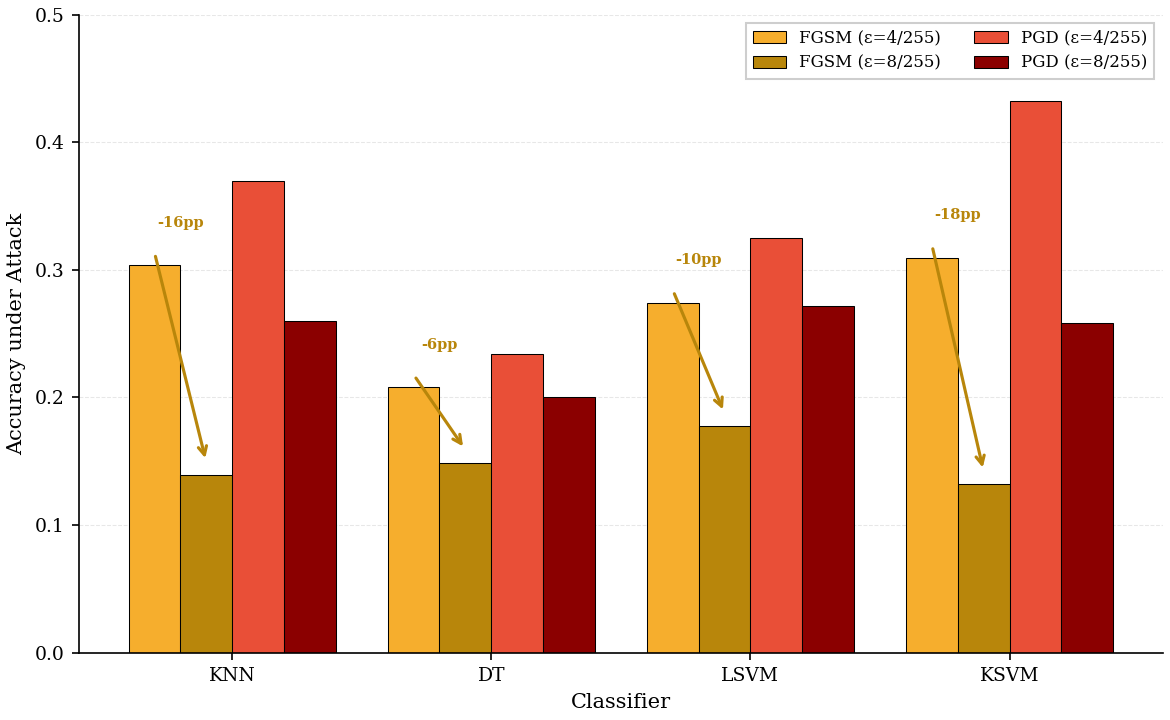

In [8]:
def figure4_epsilon_sensitivity():
    """Perturbation budget sensitivity."""
    # C1 (exp0, eps=4) vs C8 (exp7, eps=8)
    c1 = df[df['experiment'] == 0].copy()
    c8 = df[df['experiment'] == 7].copy()
    
    classifiers = ['KNN', 'DT', 'LSVM', 'KSVM']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(classifiers))
    width = 0.2
    
    eps4_fsgm = [c1[c1['classifier'] == c]['fsgm_acc'].values[0] for c in classifiers]
    eps8_fsgm = [c8[c8['classifier'] == c]['fsgm_acc'].values[0] for c in classifiers]
    eps4_pgd = [c1[c1['classifier'] == c]['pgd_acc'].values[0] for c in classifiers]
    eps8_pgd = [c8[c8['classifier'] == c]['pgd_acc'].values[0] for c in classifiers]
    
    ax.bar(x - 1.5*width, eps4_fsgm, width, label='FGSM (ε=4/255)', 
           color='#F6AE2D', edgecolor='black', linewidth=0.5)
    ax.bar(x - 0.5*width, eps8_fsgm, width, label='FGSM (ε=8/255)', 
           color='#B8860B', edgecolor='black', linewidth=0.5)
    ax.bar(x + 0.5*width, eps4_pgd, width, label='PGD (ε=4/255)', 
           color='#E94F37', edgecolor='black', linewidth=0.5)
    ax.bar(x + 1.5*width, eps8_pgd, width, label='PGD (ε=8/255)', 
           color='#8B0000', edgecolor='black', linewidth=0.5)
    
    # Add drop annotations for FGSM
    for i in range(len(classifiers)):
        ax.annotate('', xy=(x[i] - 0.5*width, eps8_fsgm[i] + 0.01),
                   xytext=(x[i] - 1.5*width, eps4_fsgm[i] + 0.01),
                   arrowprops=dict(arrowstyle='->', color='#B8860B', lw=1.5))
        drop = (eps4_fsgm[i] - eps8_fsgm[i]) * 100
        ax.annotate(f'-{drop:.0f}pp', xy=(x[i] - width, max(eps4_fsgm[i], eps8_fsgm[i]) + 0.03),
                   ha='center', fontsize=7, color='#B8860B', fontweight='bold')
    
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Accuracy under Attack')
    ax.set_xticks(x)
    ax.set_xticklabels(classifiers)
    ax.set_ylim(0, 0.5)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

fig4 = figure4_epsilon_sensitivity()
fig4.savefig('fig4_epsilon_sensitivity.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 5: Retention Heatmap (COMPREHENSIVE OVERVIEW)

**Purpose**: Provide complete overview of robustness across ALL configurations.

**Note**: Tables show absolute accuracy; this shows RETENTION (%), providing complementary insight.

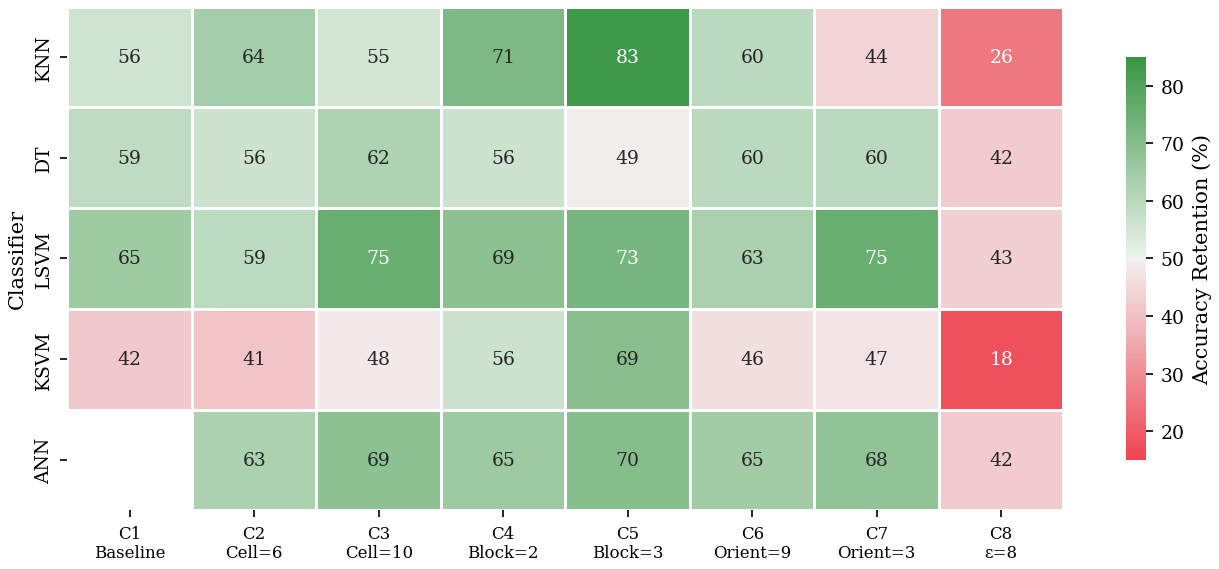

In [9]:
def figure5_retention_heatmap():
    """Comprehensive heatmap of FGSM accuracy retention."""
    pivot = df.pivot_table(
        values='fsgm_retention',
        index='classifier',
        columns='experiment',
        aggfunc='mean'
    )
    
    clf_order = ['KNN', 'DT', 'LSVM', 'KSVM', 'ANN']
    clf_order = [c for c in clf_order if c in pivot.index]
    pivot = pivot.reindex(clf_order)
    
    config_labels = ['C1\nBaseline', 'C2\nCell=6', 'C3\nCell=10', 
                     'C4\nBlock=2', 'C5\nBlock=3', 'C6\nOrient=9', 
                     'C7\nOrient=3', 'C8\nε=8']
    
    fig, ax = plt.subplots(figsize=(9, 4))
    
    cmap = sns.diverging_palette(10, 130, s=80, l=55, as_cmap=True)
    
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap,
                center=50, vmin=15, vmax=85,
                cbar_kws={'label': 'Accuracy Retention (%)', 'shrink': 0.8},
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={'fontsize': 9})
    
    ax.set_xticklabels(config_labels, rotation=0, fontsize=8)
    ax.set_ylabel('Classifier')
    ax.set_xlabel('')
    ax.annotate('↓ Worst', xy=(7.5, -0.3), xycoords='data',
               ha='center', fontsize=8, color='#CC3311', fontweight='bold')
    
    plt.tight_layout()
    return fig

fig5 = figure5_retention_heatmap()
fig5.savefig('fig5_retention_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 6: Pipeline Relative Vulnerability

**Purpose**: Compare HOG vulnerability vs CNN baseline using RELATIVE drops (normalizes for different clean accuracies).

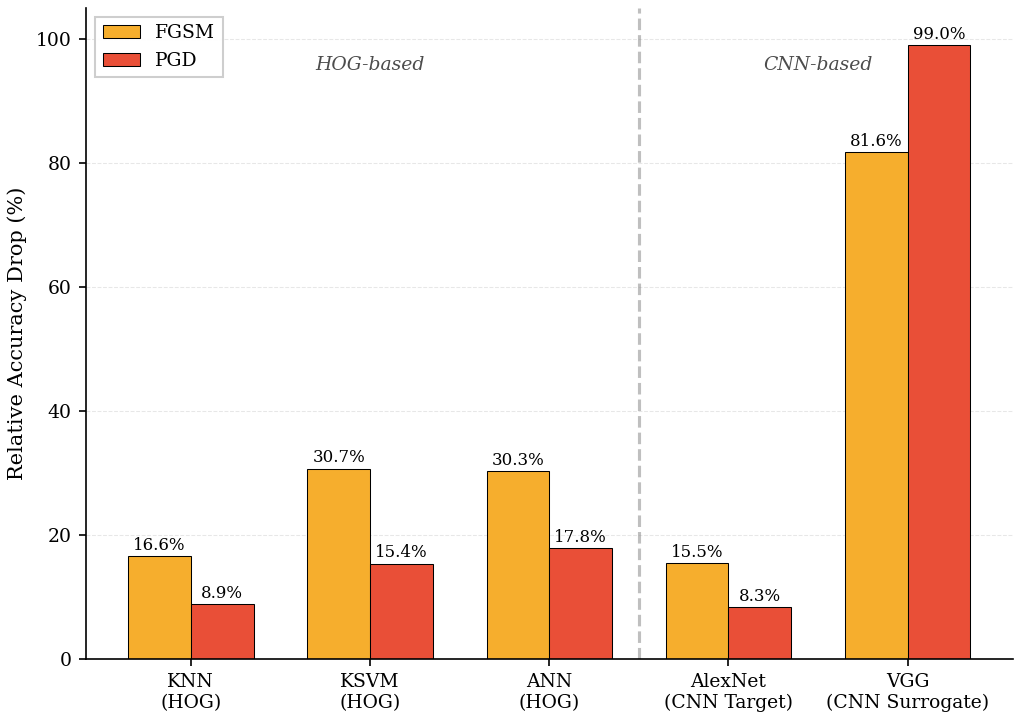

In [10]:
def figure6_pipeline_comparison():
    """Relative accuracy drop by pipeline type."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    c5 = df[df['experiment'] == 4]
    
    pipelines = ['KNN\n(HOG)', 'KSVM\n(HOG)', 'ANN\n(HOG)', 
                 'AlexNet\n(CNN Target)', 'VGG\n(CNN Surrogate)']
    
    c5_ann = c5[c5['classifier'] == 'ANN']
    
    fsgm_drops = [
        c5[c5['classifier'] == 'KNN']['fsgm_rel_drop'].values[0],
        c5[c5['classifier'] == 'KSVM']['fsgm_rel_drop'].values[0],
        c5_ann['fsgm_rel_drop'].values[0] if len(c5_ann) > 0 else 0,
        cnn_data[cnn_data['classifier'] == 'AlexNet']['fsgm_rel_drop'].values[0],
        cnn_data[cnn_data['classifier'] == 'VGG']['fsgm_rel_drop'].values[0],
    ]
    
    pgd_drops = [
        c5[c5['classifier'] == 'KNN']['pgd_rel_drop'].values[0],
        c5[c5['classifier'] == 'KSVM']['pgd_rel_drop'].values[0],
        c5_ann['pgd_rel_drop'].values[0] if len(c5_ann) > 0 else 0,
        cnn_data[cnn_data['classifier'] == 'AlexNet']['pgd_rel_drop'].values[0],
        cnn_data[cnn_data['classifier'] == 'VGG']['pgd_rel_drop'].values[0],
    ]
    
    x = np.arange(len(pipelines))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, fsgm_drops, width, label='FGSM',
                   color='#F6AE2D', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, pgd_drops, width, label='PGD',
                   color='#E94F37', edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars1, fsgm_drops):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                   xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    for bar, val in zip(bars2, pgd_drops):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                   xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    
    ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5)
    ax.text(1, 95, 'HOG-based', ha='center', fontsize=9, style='italic', alpha=0.7)
    ax.text(3.5, 95, 'CNN-based', ha='center', fontsize=9, style='italic', alpha=0.7)
    
    ax.set_ylabel('Relative Accuracy Drop (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(pipelines, fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(loc='upper left')
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig

fig6 = figure6_pipeline_comparison()
fig6.savefig('fig6_pipeline_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 7: Parameter-Robustness Correlation

**Purpose**: Quantify the relationship between HOG configuration choices and adversarial robustness.

**Important Note**: Correlations computed across configurations (n=32), NOT repeated trials. This measures **configuration sensitivity**, not measurement uncertainty.

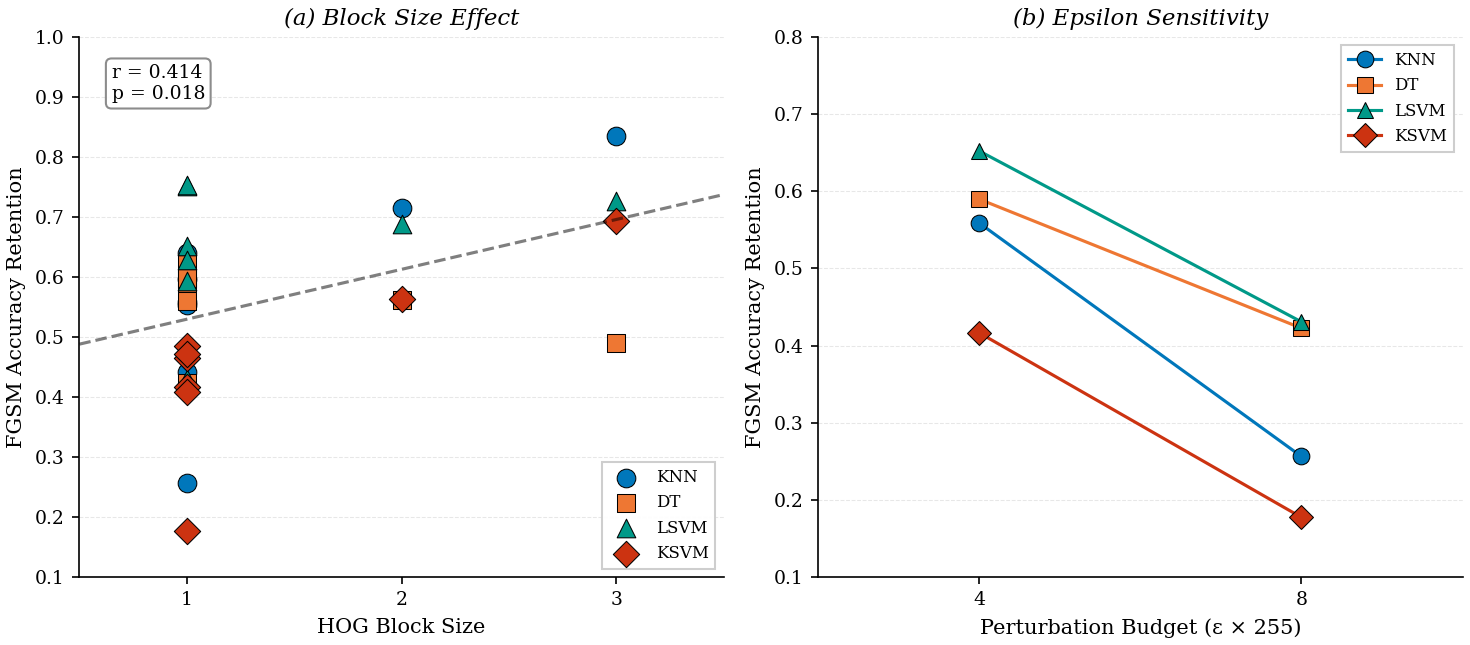

In [11]:
def figure7_correlation_analysis():
    """Correlation between HOG parameters and robustness."""
    classical = df[df['classifier'].isin(['KNN', 'DT', 'LSVM', 'KSVM'])].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # Left: Block size vs FGSM retention
    ax = axes[0]
    
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM']:
        clf_data = classical[classical['classifier'] == clf]
        ax.scatter(clf_data['block_size'], clf_data['fsgm_retention'] / 100,
                  c=COLORS[clf], marker=MARKERS[clf], s=80, label=clf,
                  edgecolors='black', linewidths=0.5)
    
    # Regression line
    x = classical['block_size'].values
    y = classical['fsgm_retention'].values / 100
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0.5, 3.5, 100)
    ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5)
    
    corr, pval = stats.pearsonr(x, y)
    ax.annotate(f'r = {corr:.3f}\np = {pval:.3f}',
               xy=(0.05, 0.95), xycoords='axes fraction', fontsize=9,
               verticalalignment='top', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_xlabel('HOG Block Size')
    ax.set_ylabel('FGSM Accuracy Retention')
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(0.1, 1.0)
    ax.set_xticks([1, 2, 3])
    ax.legend(loc='lower right', fontsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title('(a) Block Size Effect', fontweight='normal', style='italic')
    
    # Right: Epsilon sensitivity
    ax = axes[1]
    eps_data = classical[classical['experiment'].isin([0, 7])]
    
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM']:
        clf_data = eps_data[eps_data['classifier'] == clf].sort_values('epsilon')
        ax.plot(clf_data['epsilon'], clf_data['fsgm_retention'] / 100,
               'o-', color=COLORS[clf], marker=MARKERS[clf], 
               label=clf, linewidth=1.5, markersize=8,
               markeredgecolor='black', markeredgewidth=0.5)
    
    ax.set_xlabel('Perturbation Budget (ε × 255)')
    ax.set_ylabel('FGSM Accuracy Retention')
    ax.set_xticks([4, 8])
    ax.set_xlim(2, 10)
    ax.set_ylim(0.1, 0.8)
    ax.legend(loc='upper right', fontsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title('(b) Epsilon Sensitivity', fontweight='normal', style='italic')
    
    plt.tight_layout()
    return fig

fig7 = figure7_correlation_analysis()
fig7.savefig('fig7_correlation_analysis.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Figure 8: Radar Chart (SUMMARY VISUALIZATION)

**Purpose**: Intuitive multi-dimensional comparison of classifier robustness profiles.

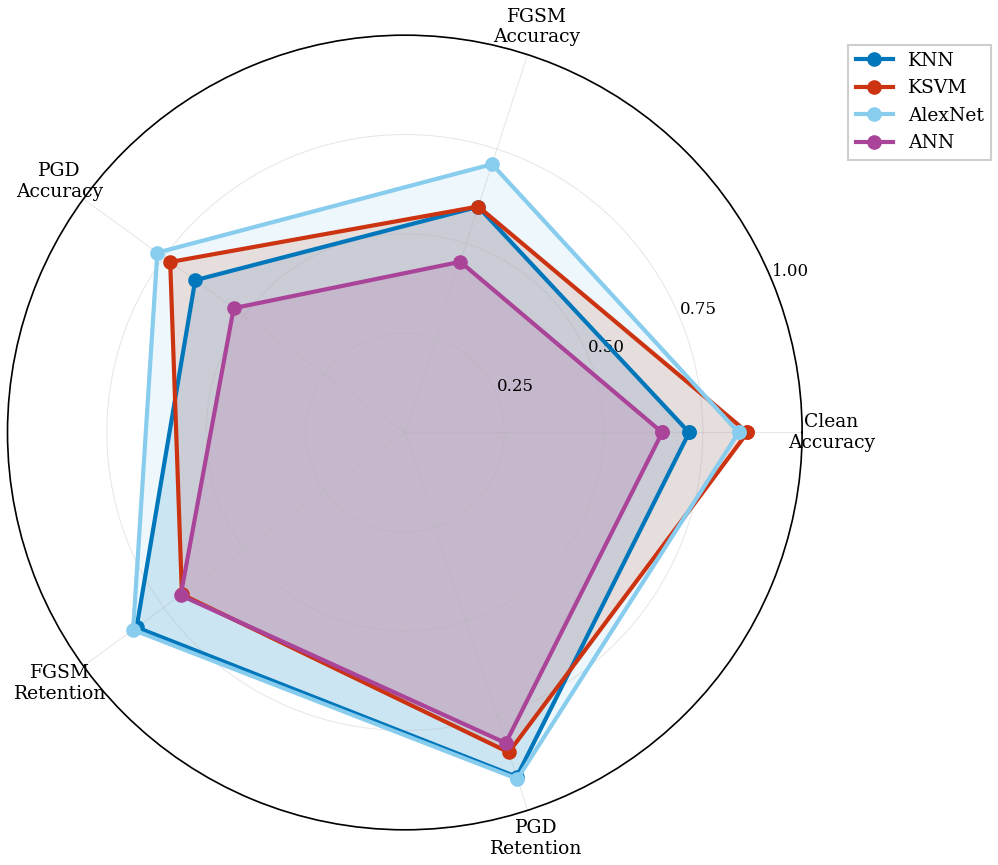

In [14]:
def figure8_radar_comparison():
    """Radar chart comparing models across multiple metrics."""
    c5 = df[df['experiment'] == 4]
    
    metrics = ['Clean\nAccuracy', 'FGSM\nAccuracy', 'PGD\nAccuracy', 
               'FGSM\nRetention', 'PGD\nRetention']
    
    models_to_plot = ['KNN', 'KSVM', 'AlexNet', "ANN"]
    data = {}
    
    for model in models_to_plot:
        if model == 'AlexNet':
            row = cnn_data[cnn_data['classifier'] == model].iloc[0]
            fsgm_ret = row['fsgm_acc'] / row['orig_acc']
            pgd_ret = row['pgd_acc'] / row['orig_acc']
        # elif:
        #     row = _data[cnn_data['classifier'] == model].iloc[0]
        #     fsgm_ret = row['fsgm_acc'] / row['orig_acc']
        #     pgd_ret = row['pgd_acc'] / row['orig_acc']
        else:
            row = c5[c5['classifier'] == model].iloc[0]
            fsgm_ret = row['fsgm_retention'] / 100
            pgd_ret = row['pgd_retention'] / 100
        
        data[model] = [
            row['orig_acc'],
            row['fsgm_acc'],
            row['pgd_acc'],
            fsgm_ret,
            pgd_ret
        ]
    
    N = len(metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))
    
    for model in models_to_plot:
        values = data[model]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=model,
                color=COLORS[model], markersize=6)
        ax.fill(angles, values, alpha=0.15, color=COLORS[model])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
    
    plt.tight_layout()
    return fig

fig8 = figure8_radar_comparison()
fig8.savefig('fig8_radar_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary

### Generated Figures:

| Figure | Description | Paper Section |
|--------|-------------|---------------|
| Fig 1 | Cross-paradigm comparison | Results (Central Finding) |
| Fig 2 | FGSM vs PGD transfer scatter | Discussion (FGSM > PGD) |
| Fig 3 | Block size mitigation | Discussion (HOG Parameters) |
| Fig 4 | Epsilon sensitivity | Discussion (Budget Sensitivity) |
| Fig 5 | Retention heatmap | Results Overview |
| Fig 6 | Pipeline relative drops | Cross-Paradigm Comparison |
| Fig 7 | Parameter correlations | Analysis |
| Fig 8 | Radar comparison | Conclusion Summary |

### Note on Statistical Analysis:
- Each experiment configuration was run **once**
- Correlations (Fig 7) measure **sensitivity to configuration changes**, not measurement uncertainty
- For true confidence intervals, experiments would need to be repeated multiple times with different random seeds

In [13]:
print("All figures saved as PDF (vector) format for publication!")
print("\nFiles generated:")
for i in range(1, 9):
    print(f"  - fig{i}_*.pdf")

All figures saved as PDF (vector) format for publication!

Files generated:
  - fig1_*.pdf
  - fig2_*.pdf
  - fig3_*.pdf
  - fig4_*.pdf
  - fig5_*.pdf
  - fig6_*.pdf
  - fig7_*.pdf
  - fig8_*.pdf


Saving 8 figures in academic style (SVG format)...
  - Saved fig1_cross_paradigm.svg
  - Saved fig2_transfer_scatter.svg
  - Saved fig3_block_size.svg
  - Saved fig4_epsilon_sensitivity.svg
  - Saved fig5_retention_heatmap.svg
  - Saved fig6_pipeline_comparison.svg
  - Saved fig7_parameter_correlation.svg
  - Saved fig8_radar_summary.svg


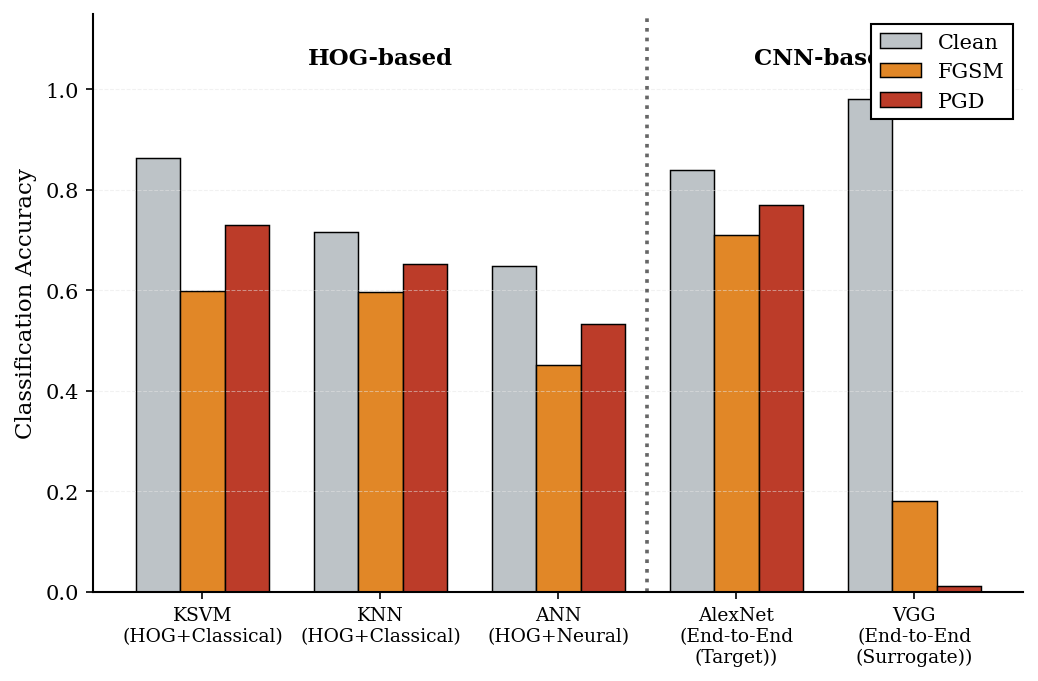

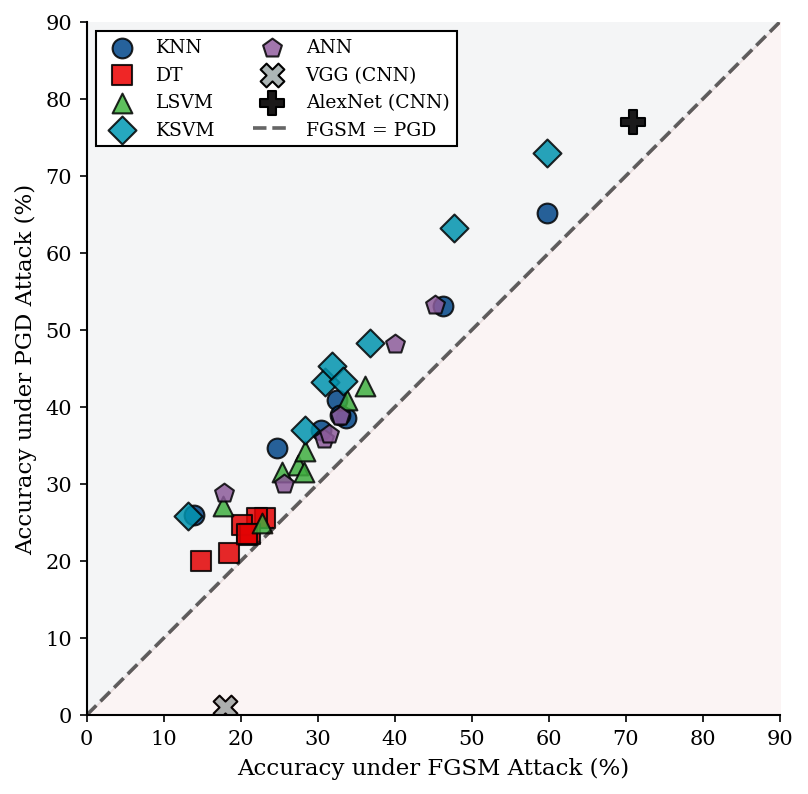

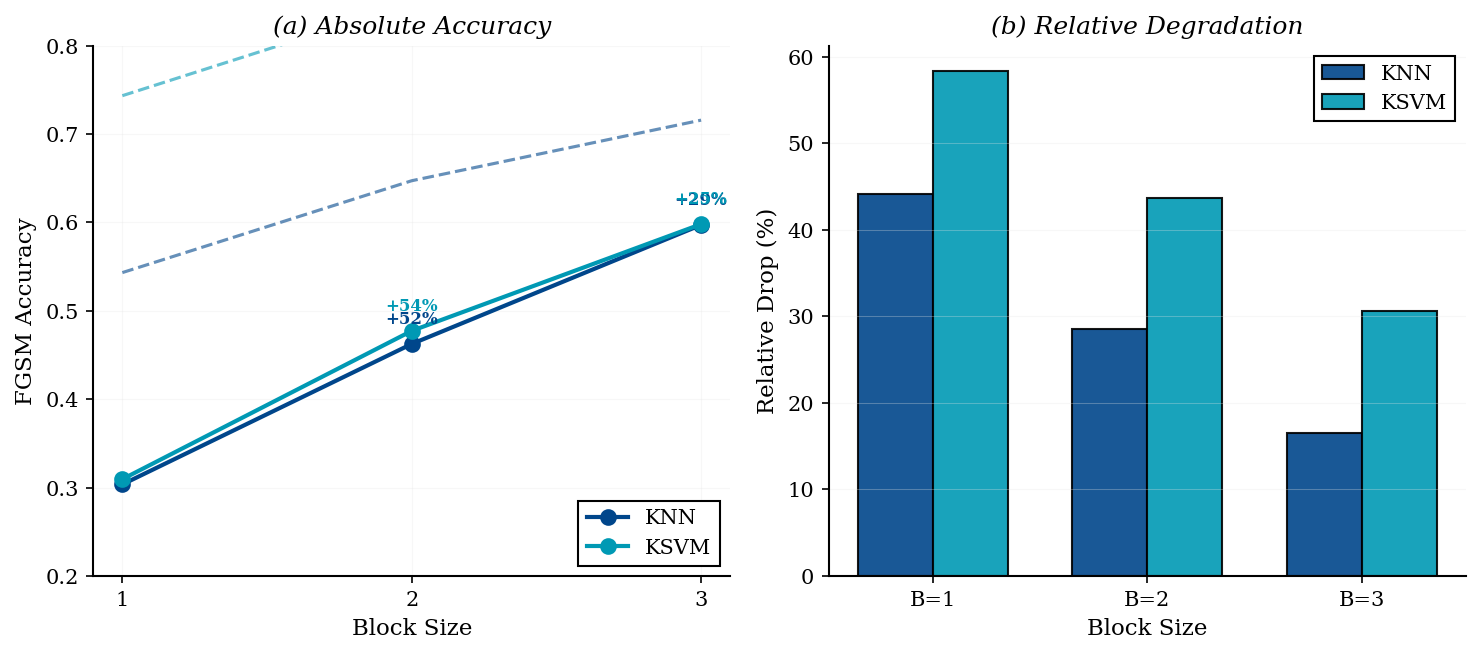

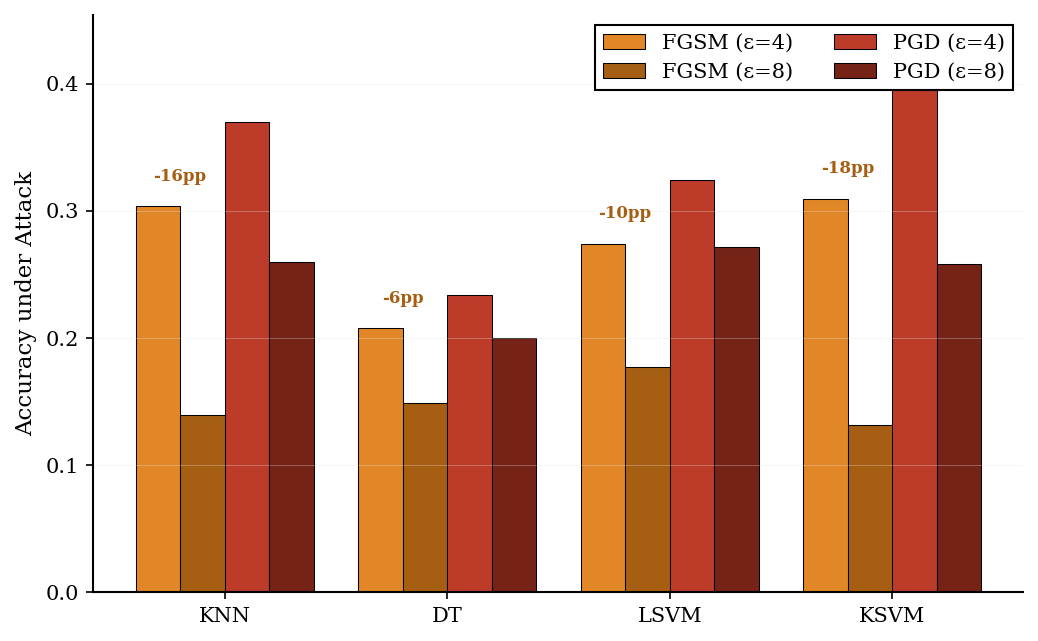

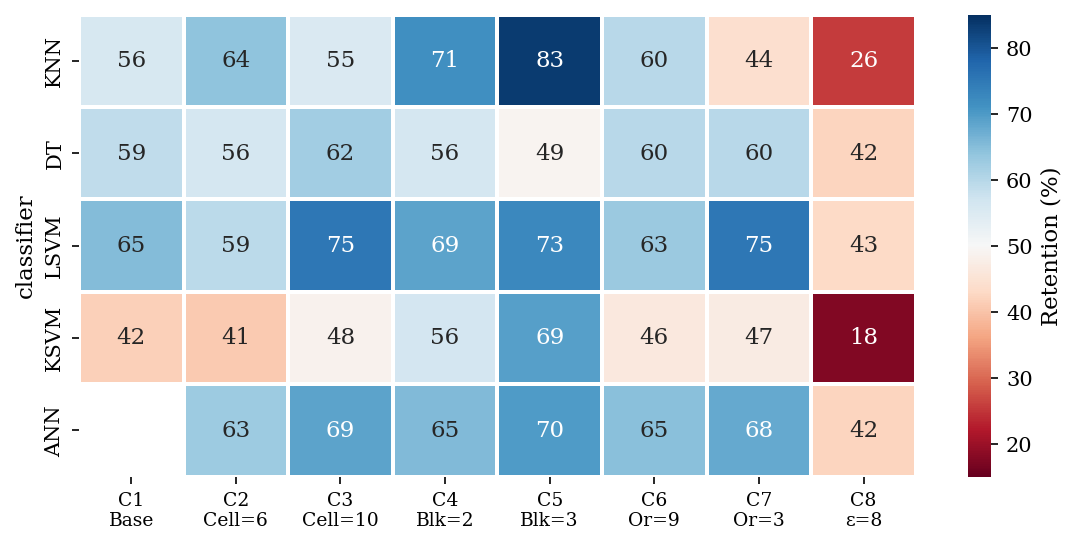

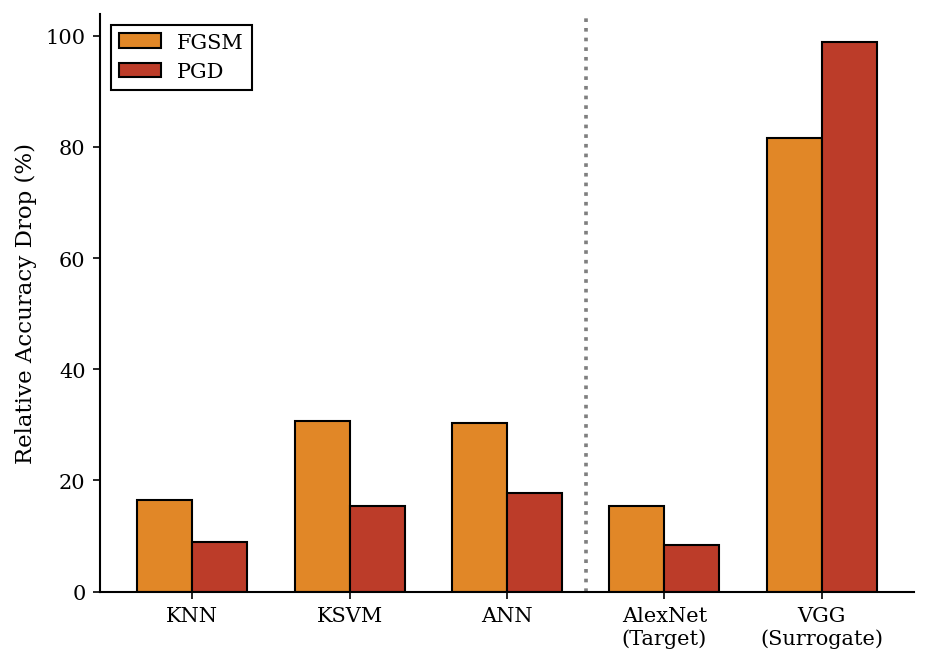

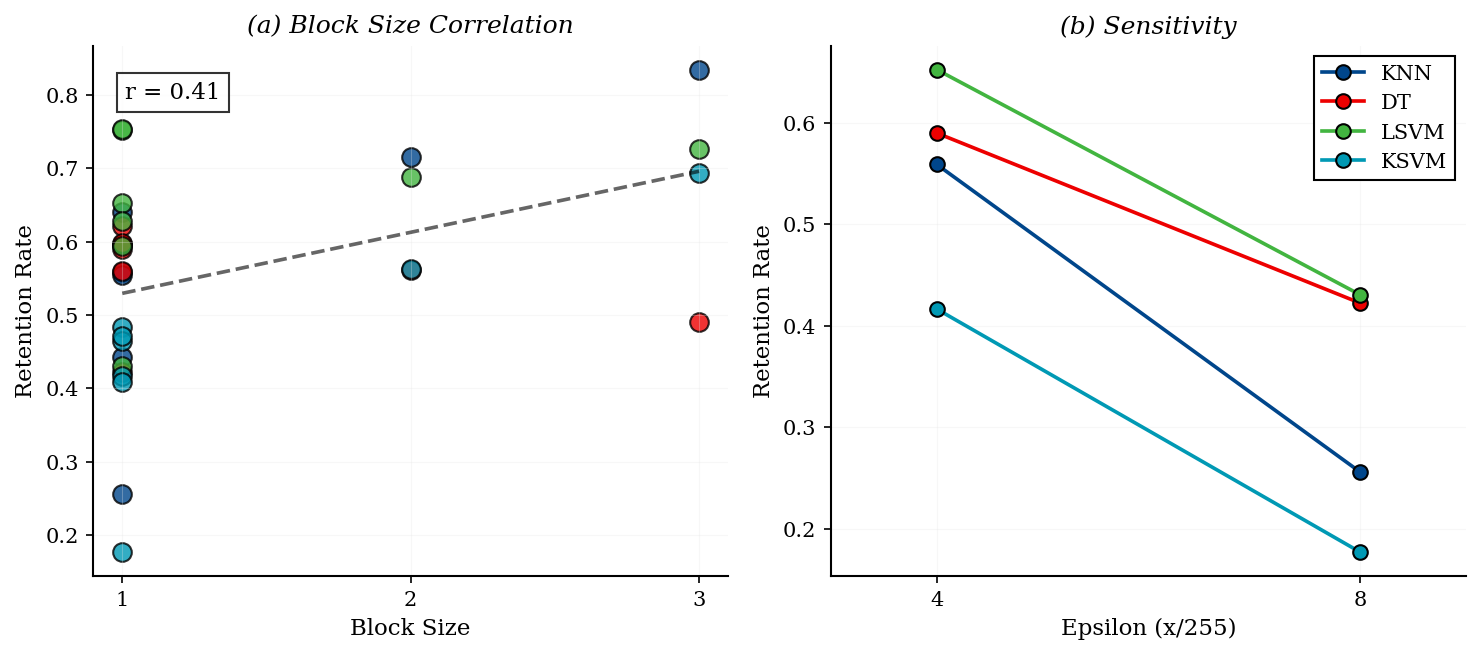

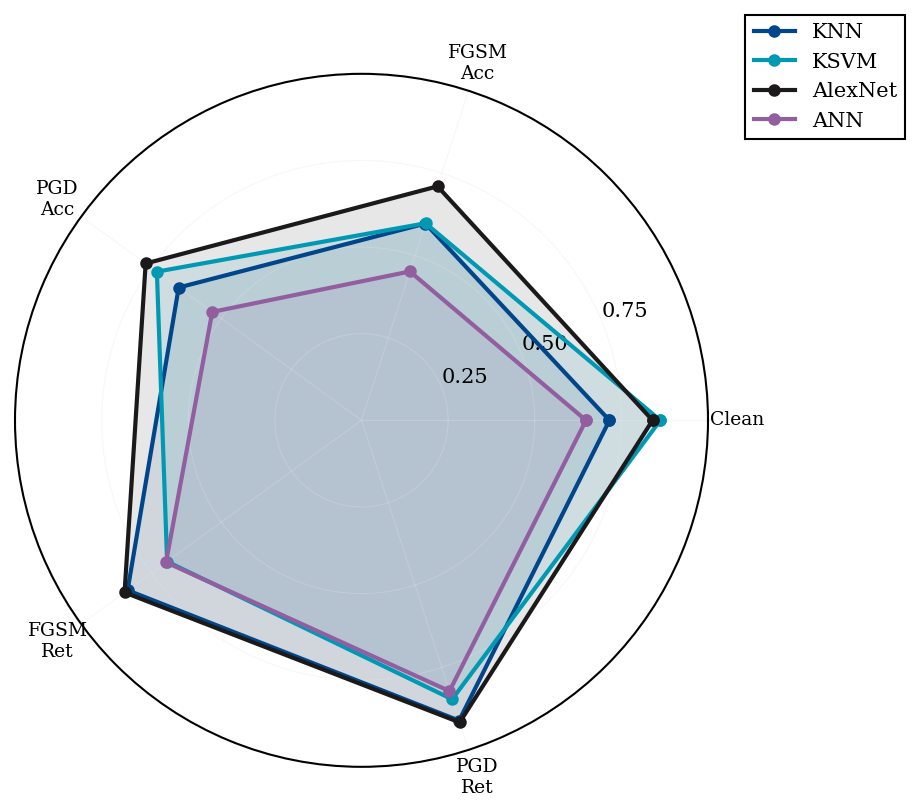

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from math import pi
import warnings

# --- 1. Publication Style & Palette Configuration ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.format': 'svg',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'lines.linewidth': 1.75,
    'lines.markersize': 7,
    'grid.color': '#E5E5E5',
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'legend.frameon': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
})

# -- Academic Palette (Lancet/NEJM Inspired) --
COLORS = {
    'KNN':     '#00468B',  # Navy
    'DT':      '#ED0000',  # Crimson
    'LSVM':    '#42B540',  # Forest Green
    'KSVM':    '#0099B4',  # Teal
    'ANN':     '#925E9F',  # Purple
    'VGG':     '#ADB6B6',  # Slate (Surrogate)
    'AlexNet': '#1B1919',  # Charcoal (Target)
}

# Condition Colors (Low vs High Epsilon)
COND_COLORS = {
    'Clean':     '#BDC3C7', # Light Grey
    'FGSM':      '#E18727', # Orange
    'FGSM_High': '#A65E12', # Dark Orange
    'PGD':       '#BC3C29', # Red
    'PGD_High':  '#752217', # Dark Red
}

MARKERS = {
    'KNN': 'o', 'DT': 's', 'LSVM': '^', 'KSVM': 'D', 
    'ANN': 'p', 'VGG': 'X', 'AlexNet': 'P'
}

# --- 2. Data Preparation (Requires your JSONs to be loaded) ---
# Ensure 'results', 'results_ann', and 'configs' are loaded in previous cells
def prepare_dataframe():
    data = []
    classifiers = ['KNN', 'DT', 'LSVM', 'KSVM']
    
    for i, config in enumerate(configs):
        exp_key = f'EXPERIMENT{i}'
        for clf in classifiers:
            if exp_key in results and clf in results[exp_key]:
                data.append({
                    'experiment': i,
                    'classifier': clf,
                    'pipeline': 'HOG+Classical',
                    'cell_size': config['PXCELL'],
                    'orientations': config['ORIENTATIONS'],
                    'block_size': config['CELLBLOCK'],
                    'epsilon': config['EPS'],
                    'orig_acc': results[exp_key][clf]['orig_acc'],
                    'fsgm_acc': results[exp_key][clf]['fsgm_acc'],
                    'pgd_acc': results[exp_key][clf]['pgd_acc'],
                })
        
        if exp_key in results_ann and 'ANN' in results_ann[exp_key]:
            ann_orig = results_ann[exp_key]['ANN']['orig_acc']
            if ann_orig > 0.15:
                data.append({
                    'experiment': i,
                    'classifier': 'ANN',
                    'pipeline': 'HOG+Neural',
                    'cell_size': config['PXCELL'],
                    'orientations': config['ORIENTATIONS'],
                    'block_size': config['CELLBLOCK'],
                    'epsilon': config['EPS'],
                    'orig_acc': ann_orig,
                    'fsgm_acc': results_ann[exp_key]['ANN']['fsgm_acc'],
                    'pgd_acc': results_ann[exp_key]['ANN']['pgd_acc'],
                })
    
    df = pd.DataFrame(data)
    df['fsgm_drop'] = df['orig_acc'] - df['fsgm_acc']
    df['pgd_drop'] = df['orig_acc'] - df['pgd_acc']
    df['fsgm_rel_drop'] = (df['orig_acc'] - df['fsgm_acc']) / df['orig_acc'] * 100
    df['pgd_rel_drop'] = (df['orig_acc'] - df['pgd_acc']) / df['orig_acc'] * 100
    df['fsgm_retention'] = df['fsgm_acc'] / df['orig_acc'] * 100
    df['pgd_retention'] = df['pgd_acc'] / df['orig_acc'] * 100
    return df

cnn_data = pd.DataFrame([
    {'classifier': 'VGG', 'pipeline': 'End-to-End (Surrogate)', 'orig_acc': 0.98, 'fsgm_acc': 0.18, 'pgd_acc': 0.01},
    {'classifier': 'AlexNet', 'pipeline': 'End-to-End (Target)', 'orig_acc': 0.84, 'fsgm_acc': 0.71, 'pgd_acc': 0.77},
])
cnn_data['fsgm_rel_drop'] = (cnn_data['orig_acc'] - cnn_data['fsgm_acc']) / cnn_data['orig_acc'] * 100
cnn_data['pgd_rel_drop'] = (cnn_data['orig_acc'] - cnn_data['pgd_acc']) / cnn_data['orig_acc'] * 100

df = prepare_dataframe()

# --- 3. Figure Generation Functions ---

def fig1_cross_paradigm():
    """Figure 1: Cross-Paradigm Comparison"""
    c5 = df[df['experiment'] == 4].copy()
    models = ['KSVM', 'KNN', 'ANN', 'AlexNet', 'VGG']
    pipelines = ['HOG+Classical', 'HOG+Classical', 'HOG+Neural', 'End-to-End\n(Target)', 'End-to-End\n(Surrogate)']
    
    orig, fsgm, pgd = [], [], []
    for m in models:
        row = cnn_data[cnn_data['classifier'] == m].iloc[0] if m in ['VGG', 'AlexNet'] else c5[c5['classifier'] == m].iloc[0]
        orig.append(row['orig_acc'])
        fsgm.append(row['fsgm_acc'])
        pgd.append(row['pgd_acc'])
    
    fig, ax = plt.subplots(figsize=(8, 5))
    x, width = np.arange(len(models)), 0.25
    
    ax.bar(x - width, orig, width, label='Clean', color=COND_COLORS['Clean'], edgecolor='black', lw=0.7)
    ax.bar(x, fsgm, width, label='FGSM', color=COND_COLORS['FGSM'], edgecolor='black', lw=0.7)
    ax.bar(x + width, pgd, width, label='PGD', color=COND_COLORS['PGD'], edgecolor='black', lw=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{m}\n({p})' for m, p in zip(models, pipelines)], fontsize=9)
    ax.axvline(x=2.5, color='black', linestyle=':', alpha=0.6)
    ax.text(1, 1.05, 'HOG-based', ha='center', weight='bold')
    ax.text(3.5, 1.05, 'CNN-based', ha='center', weight='bold')
    ax.set_ylabel('Classification Accuracy')
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    return fig

def fig2_transfer_scatter():
    """Figure 2: FGSM vs PGD Scatter"""
    fig, ax = plt.subplots(figsize=(6, 6))
    
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM', 'ANN']:
        d = df[df['classifier'] == clf]
        if len(d) > 0:
            ax.scatter(d['fsgm_acc']*100, d['pgd_acc']*100, c=COLORS[clf], marker=MARKERS[clf], 
                       s=90, label=clf, edgecolors='black', alpha=0.85)
            
    for _, row in cnn_data.iterrows():
        clf = row['classifier']
        ax.scatter(row['fsgm_acc']*100, row['pgd_acc']*100, c=COLORS[clf], marker=MARKERS[clf], 
                   s=130, label=f'{clf} (CNN)', edgecolors='black')

    ax.plot([0, 100], [0, 100], 'k--', alpha=0.6, label='FGSM = PGD')
    ax.fill_between([0, 100], [0, 100], [100, 100], alpha=0.05, color='#2E4053')
    ax.fill_between([0, 100], [0, 0], [0, 100], alpha=0.05, color='#C0392B')
    
    ax.set_xlabel('Accuracy under FGSM Attack (%)')
    ax.set_ylabel('Accuracy under PGD Attack (%)')
    ax.set_xlim(0, 90); ax.set_ylim(0, 90)
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.set_aspect('equal')
    return fig

def fig3_block_size():
    """Figure 3: Block Size Impact"""
    data = df[(df['experiment'].isin([0, 3, 4])) & (df['classifier'].isin(['KNN', 'KSVM']))].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # Panel A: Absolute Accuracy
    ax = axes[0]
    for clf in ['KNN', 'KSVM']:
        d = data[data['classifier'] == clf].sort_values('block_size')
        ax.plot(d['block_size'], d['orig_acc'], '--', color=COLORS[clf], alpha=0.6, lw=1.5)
        ax.plot(d['block_size'], d['fsgm_acc'], 'o-', color=COLORS[clf], label=clf, lw=2)
        
        # Annotate gain
        vals, sizes = d['fsgm_acc'].values, d['block_size'].values
        for i in range(1, len(vals)):
            gain = (vals[i] - vals[i-1]) / vals[i-1] * 100
            ax.annotate(f'+{gain:.0f}%', xy=(sizes[i], vals[i]), xytext=(0, 10), 
                       textcoords='offset points', ha='center', fontsize=8, color=COLORS[clf], weight='bold')

    ax.set_xlabel('Block Size'); ax.set_ylabel('FGSM Accuracy')
    ax.set_xticks([1, 2, 3]); ax.set_ylim(0.2, 0.8)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_title('(a) Absolute Accuracy', style='italic')

    # Panel B: Relative Drop
    ax = axes[1]
    x, width = np.arange(3), 0.35
    for i, clf in enumerate(['KNN', 'KSVM']):
        d = data[data['classifier'] == clf].sort_values('block_size')
        ax.bar(x + (i-0.5)*width, d['fsgm_rel_drop'], width, label=clf, 
               color=COLORS[clf], edgecolor='black', alpha=0.9)

    ax.set_xlabel('Block Size'); ax.set_ylabel('Relative Drop (%)')
    ax.set_xticks(x); ax.set_xticklabels(['B=1', 'B=2', 'B=3'])
    ax.legend(loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_title('(b) Relative Degradation', style='italic')
    
    plt.tight_layout()
    return fig

def fig4_epsilon():
    """Figure 4: Epsilon Sensitivity"""
    c1 = df[df['experiment'] == 0].copy() # Eps 4
    c8 = df[df['experiment'] == 7].copy() # Eps 8
    clfs = ['KNN', 'DT', 'LSVM', 'KSVM']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    x, width = np.arange(len(clfs)), 0.2
    
    # Extract values
    e4_fgsm = [c1[c1['classifier']==c]['fsgm_acc'].values[0] for c in clfs]
    e8_fgsm = [c8[c8['classifier']==c]['fsgm_acc'].values[0] for c in clfs]
    e4_pgd  = [c1[c1['classifier']==c]['pgd_acc'].values[0] for c in clfs]
    e8_pgd  = [c8[c8['classifier']==c]['pgd_acc'].values[0] for c in clfs]
    
    # Plot using Condition Colors
    ax.bar(x - 1.5*width, e4_fgsm, width, label='FGSM (ε=4)', color=COND_COLORS['FGSM'], edgecolor='black', lw=0.5)
    ax.bar(x - 0.5*width, e8_fgsm, width, label='FGSM (ε=8)', color=COND_COLORS['FGSM_High'], edgecolor='black', lw=0.5)
    ax.bar(x + 0.5*width, e4_pgd, width, label='PGD (ε=4)', color=COND_COLORS['PGD'], edgecolor='black', lw=0.5)
    ax.bar(x + 1.5*width, e8_pgd, width, label='PGD (ε=8)', color=COND_COLORS['PGD_High'], edgecolor='black', lw=0.5)
    
    # Annotations
    for i in range(len(clfs)):
        drop = (e4_fgsm[i] - e8_fgsm[i]) * 100
        ax.annotate(f'-{drop:.0f}pp', xy=(x[i]-width, max(e4_fgsm[i], e8_fgsm[i])+0.02), 
                   ha='center', fontsize=8, weight='bold', color=COND_COLORS['FGSM_High'])
        
    ax.set_xticks(x); ax.set_xticklabels(clfs)
    ax.set_ylabel('Accuracy under Attack')
    ax.legend(ncol=2, loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    return fig

def fig5_heatmap():
    """Figure 5: Retention Heatmap"""
    pivot = df.pivot_table(values='fsgm_retention', index='classifier', columns='experiment', aggfunc='mean')
    pivot = pivot.reindex(['KNN', 'DT', 'LSVM', 'KSVM', 'ANN'])
    labels = ['C1\nBase', 'C2\nCell=6', 'C3\nCell=10', 'C4\nBlk=2', 'C5\nBlk=3', 'C6\nOr=9', 'C7\nOr=3', 'C8\nε=8']
    
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap="RdBu", center=50, vmin=15, vmax=85,
                cbar_kws={'label': 'Retention (%)'}, linewidths=1, linecolor='white', ax=ax)
    ax.set_xticklabels(labels, fontsize=9); ax.set_xlabel('')
    return fig

def fig6_pipelines():
    """Figure 6: Pipeline Comparison"""
    c5 = df[df['experiment'] == 4]
    c5_ann = c5[c5['classifier'] == 'ANN']
    
    # Drops
    fsgm = [c5[c5['classifier']==c]['fsgm_rel_drop'].values[0] for c in ['KNN', 'KSVM']] + \
           [c5_ann['fsgm_rel_drop'].values[0] if len(c5_ann) > 0 else 0] + \
           [cnn_data[cnn_data['classifier']==c]['fsgm_rel_drop'].values[0] for c in ['AlexNet', 'VGG']]
           
    pgd = [c5[c5['classifier']==c]['pgd_rel_drop'].values[0] for c in ['KNN', 'KSVM']] + \
          [c5_ann['pgd_rel_drop'].values[0] if len(c5_ann) > 0 else 0] + \
          [cnn_data[cnn_data['classifier']==c]['pgd_rel_drop'].values[0] for c in ['AlexNet', 'VGG']]

    names = ['KNN', 'KSVM', 'ANN', 'AlexNet\n(Target)', 'VGG\n(Surrogate)']
    
    fig, ax = plt.subplots(figsize=(7, 5))
    x, width = np.arange(len(names)), 0.35
    
    ax.bar(x - width/2, fsgm, width, label='FGSM', color=COND_COLORS['FGSM'], edgecolor='black')
    ax.bar(x + width/2, pgd, width, label='PGD', color=COND_COLORS['PGD'], edgecolor='black')
    
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylabel('Relative Accuracy Drop (%)')
    ax.legend(loc='upper left')
    ax.axvline(x=2.5, color='black', linestyle=':', alpha=0.5)
    return fig

def fig7_correlation():
    """Figure 7: Correlation Analysis"""
    classical = df[df['classifier'].isin(['KNN', 'DT', 'LSVM', 'KSVM'])].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # Panel A: Block Size
    ax = axes[0]
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM']:
        d = classical[classical['classifier'] == clf]
        ax.scatter(d['block_size'], d['fsgm_retention']/100, c=COLORS[clf], s=80, edgecolor='black', alpha=0.8)
    
    # Regression
    x, y = classical['block_size'], classical['fsgm_retention']/100
    z = np.polyfit(x, y, 1)
    ax.plot(np.unique(x), np.poly1d(z)(np.unique(x)), 'k--', alpha=0.6)
    
    corr, _ = stats.pearsonr(x, y)
    ax.text(0.05, 0.9, f'r = {corr:.2f}', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Block Size'); ax.set_ylabel('Retention Rate')
    ax.set_title('(a) Block Size Correlation', style='italic')
    ax.set_xticks([1, 2, 3]); ax.grid(True, alpha=0.3)

    # Panel B: Epsilon
    ax = axes[1]
    eps = df[df['experiment'].isin([0, 7]) & df['classifier'].isin(['KNN', 'DT', 'LSVM', 'KSVM'])]
    for clf in ['KNN', 'DT', 'LSVM', 'KSVM']:
        d = eps[eps['classifier'] == clf].sort_values('epsilon')
        ax.plot(d['epsilon'], d['fsgm_retention']/100, 'o-', c=COLORS[clf], label=clf, markeredgecolor='black')
        
    ax.set_xlabel('Epsilon (x/255)'); ax.set_ylabel('Retention Rate')
    ax.set_xticks([4, 8]); ax.set_xlim(3, 9)
    ax.legend()
    ax.set_title('(b) Sensitivity', style='italic')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def fig8_radar():
    """Figure 8: Radar Chart"""
    c5 = df[df['experiment'] == 4]
    metrics = ['Clean', 'FGSM\nAcc', 'PGD\nAcc', 'FGSM\nRet', 'PGD\nRet']
    models = ['KNN', 'KSVM', 'AlexNet', 'ANN']
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]
    
    for m in models:
        if m == 'AlexNet':
            row = cnn_data[cnn_data['classifier'] == m].iloc[0]
            vals = [row['orig_acc'], row['fsgm_acc'], row['pgd_acc'], 
                    row['fsgm_acc']/row['orig_acc'], row['pgd_acc']/row['orig_acc']]
        else:
            row = c5[c5['classifier'] == m].iloc[0]
            vals = [row['orig_acc'], row['fsgm_acc'], row['pgd_acc'], 
                    row['fsgm_retention']/100, row['pgd_retention']/100]
        
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', linewidth=2, color=COLORS[m], label=m, markersize=5)
        ax.fill(angles, vals, color=COLORS[m], alpha=0.1)

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    return fig

# --- 4. Execution & Saving ---
figures = {
    'fig1_cross_paradigm': fig1_cross_paradigm(),
    'fig2_transfer_scatter': fig2_transfer_scatter(),
    'fig3_block_size': fig3_block_size(),
    'fig4_epsilon_sensitivity': fig4_epsilon(),
    'fig5_retention_heatmap': fig5_heatmap(),
    'fig6_pipeline_comparison': fig6_pipelines(),
    'fig7_parameter_correlation': fig7_correlation(),
    'fig8_radar_summary': fig8_radar()
}

print(f"Saving {len(figures)} figures in academic style (SVG format)...")
for name, fig in figures.items():
    fig.savefig(f'/home/achraf/Research/MLHACK_PAPER/Figures/{name}.svg')
    print(f"  - Saved {name}.svg")

plt.show()